In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import random
import time
import warnings

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# The PTB dataset from PhysioNet is commonly distributed as two CSVs:
#   ptbdb_normal.csv  → class 0 (Normal)
#   ptbdb_abnormal.csv → class 1 (Abnormal)
# Alternatively a combined file (ptbdb_data.csv) may be available.

try:
    normal   = pd.read_csv('ptbdb_normal.csv',   header=None)
    abnormal = pd.read_csv('ptbdb_abnormal.csv', header=None)
    normal[187]   = 0
    abnormal[187] = 1
    data = pd.concat([normal, abnormal], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
    X = data.iloc[:, :187].values
    y = data.iloc[:, 187].values
    print('Loaded from ptbdb_normal / ptbdb_abnormal CSV files.')
except FileNotFoundError:
    try:
        data = pd.read_csv('ptbdb_data.csv', header=None)
        X = data.iloc[:, :-1].values
        y = data.iloc[:, -1].values
        print('Loaded from ptbdb_data.csv.')
    except FileNotFoundError:
        print('[WARNING] Dataset file not found — using synthetic data for demonstration.')
        print('Please place ptbdb_normal.csv & ptbdb_abnormal.csv in the working directory.')
        X = np.random.randn(14552, 187)
        y = np.random.choice([0, 1], size=14552, p=[0.72, 0.28])

print(f'\nDataset shape : X={X.shape}, y={y.shape}')
print(f'Class 0 (Normal)   : {np.sum(y==0):,}  ({np.mean(y==0)*100:.1f}%)')
print(f'Class 1 (Abnormal) : {np.sum(y==1):,}  ({np.mean(y==1)*100:.1f}%)')

[WARNING] Dataset file not found — using synthetic data for demonstration.
Please place ptbdb_normal.csv & ptbdb_abnormal.csv in the working directory.

Dataset shape : X=(14552, 187), y=(14552,)
Class 0 (Normal)   : 10,501  (72.2%)
Class 1 (Abnormal) : 4,051  (27.8%)


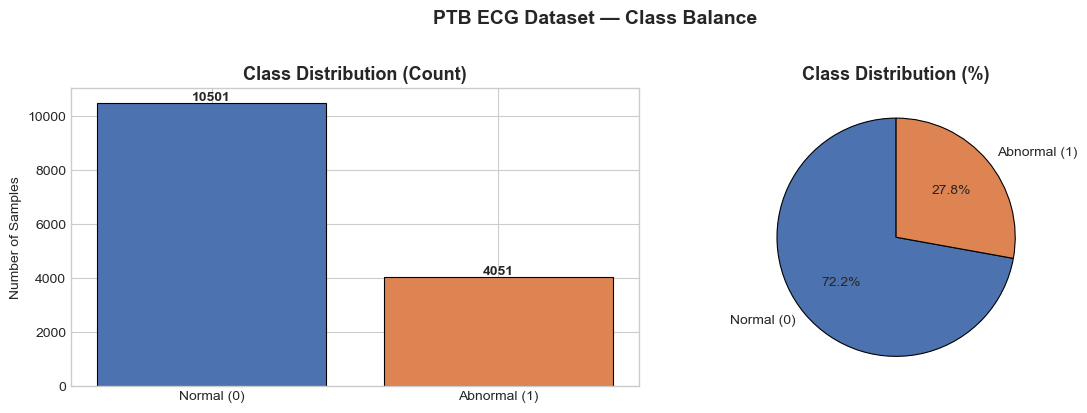

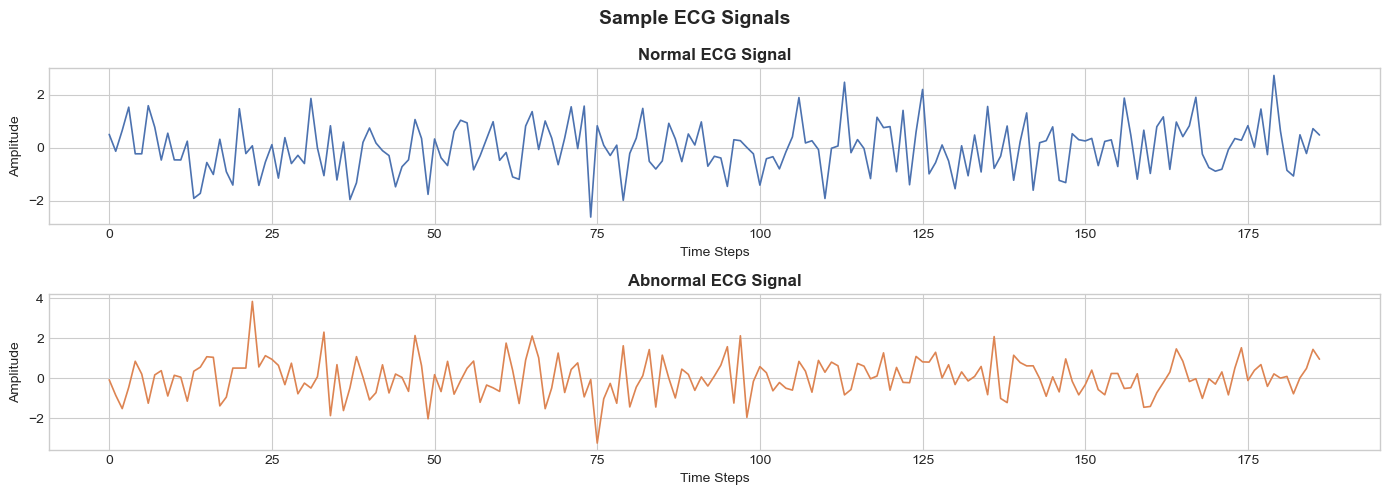

In [5]:
# ── Visualise class distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = [np.sum(y==0), np.sum(y==1)]
labels = ['Normal (0)', 'Abnormal (1)']
colors = ['#4C72B0', '#DD8452']

axes[0].bar(labels, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('PTB ECG Dataset — Class Balance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sample ECG signals ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
for cls, ax, title, color in zip([0, 1], axes,
                                  ['Normal ECG Signal', 'Abnormal ECG Signal'],
                                  ['#4C72B0', '#DD8452']):
    idx = np.where(y == cls)[0][0]
    ax.plot(X[idx], color=color, linewidth=1.2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Amplitude')

plt.suptitle('Sample ECG Signals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_sample_ecg.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Stratified split  60 / 20 / 20 ───────────────────────────────────────────
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# 0.25 of 80% = 20% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# ── Standardisation (fit ONLY on train) ───────────────────────────────────────
scaler = StandardScaler()
X_train     = scaler.fit_transform(X_train)
X_val       = scaler.transform(X_val)
X_test      = scaler.transform(X_test)
X_train_val = scaler.transform(X_train_val)   # for GA cross-validation

# ── Class weights (handle imbalance) ──────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
CLASS_WEIGHTS = dict(enumerate(cw))

print('Split sizes:')
print(f'  Train      : {X_train.shape[0]:,} samples')
print(f'  Validation : {X_val.shape[0]:,} samples')
print(f'  Test       : {X_test.shape[0]:,} samples')
print(f'\nClass weights : {CLASS_WEIGHTS}')
print(f'Input features : {X_train.shape[1]}')

Split sizes:
  Train      : 8,730 samples
  Validation : 2,911 samples
  Test       : 2,911 samples

Class weights : {0: np.float64(0.6929671376408953), 1: np.float64(1.795557383792678)}
Input features : 187


In [7]:
def create_baseline_model(input_dim: int) -> Sequential:
    """2 hidden layers × 128 neurons, ReLU, sigmoid output — no regularisation."""
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(1,   activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


baseline_model = create_baseline_model(X_train.shape[1])
baseline_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

history_base = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=CLASS_WEIGHTS,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,705 (159.00 KB)

 Trainable params: 40,705 (159.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5042 - loss: 0.7120 - val_accuracy: 0.5301 - val_loss: 0.6929
Epoch 2/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6378 - loss: 0.6438 - val_accuracy: 0.5198 - val_loss: 0.7048
Epoch 3/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7291 - loss: 0.5663 - val_accuracy: 0.5050 - val_loss: 0.7387
Epoch 4/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8115 - loss: 0.4584 - val_accuracy: 0.5294 - val_loss: 0.7729
Epoch 5/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8858 - loss: 0.3296 - val_accuracy: 0.5572 - val_loss: 0.8320
Epoch 6/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9451 - loss: 0.2097 - val_accuracy: 0.5771 - val_loss: 0.9514
Epoch 7/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9770 - loss: 0.1241 - val_accuracy: 0.5795 - val_loss: 1.1115
Epoch 8/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9888 - loss: 0.0821 - val_accu

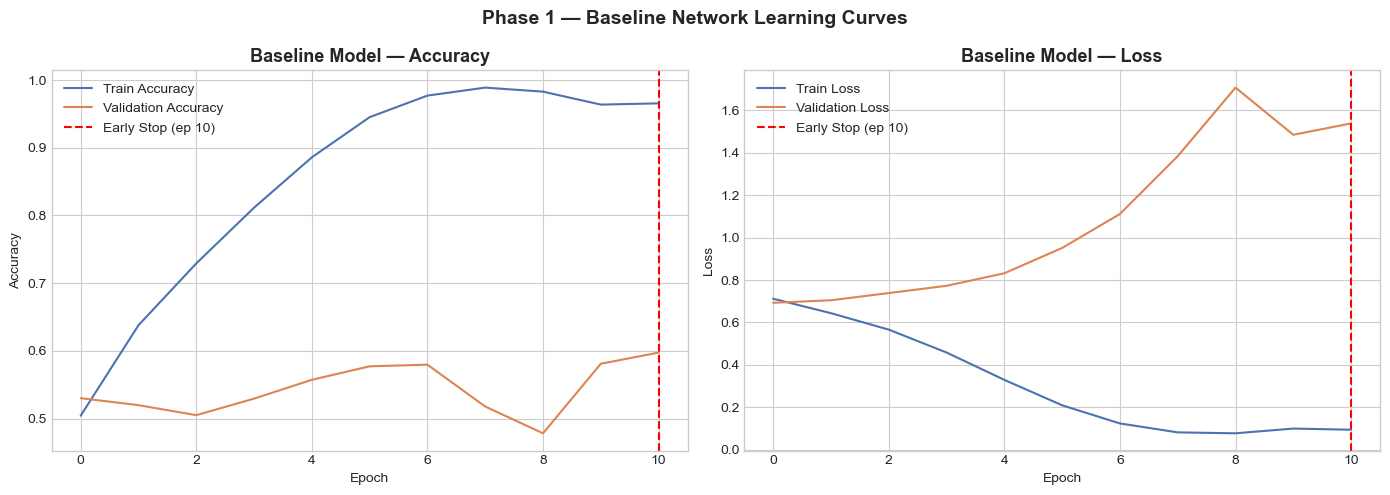

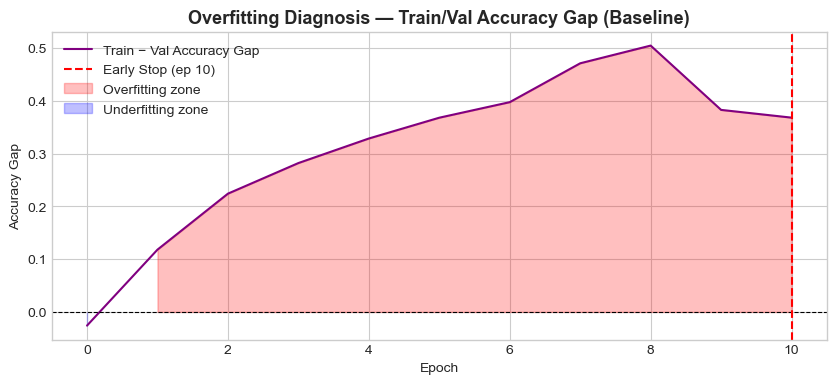

In [6]:
# ── Baseline learning curves ───────────────────────────────────────────────────
stopped_epoch = early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else len(history_base.history['loss']) - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_base.history['accuracy'],     label='Train Accuracy',      color='#4C72B0')
axes[0].plot(history_base.history['val_accuracy'], label='Validation Accuracy', color='#DD8452')
axes[0].axvline(x=stopped_epoch, color='red', linestyle='--', label=f'Early Stop (ep {stopped_epoch})')
axes[0].set_title('Baseline Model — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_base.history['loss'],     label='Train Loss',      color='#4C72B0')
axes[1].plot(history_base.history['val_loss'], label='Validation Loss', color='#DD8452')
axes[1].axvline(x=stopped_epoch, color='red', linestyle='--', label=f'Early Stop (ep {stopped_epoch})')
axes[1].set_title('Baseline Model — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Phase 1 — Baseline Network Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_baseline_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Overfitting diagnosis: accuracy gap ───────────────────────────────────────
gap = np.array(history_base.history['accuracy']) - np.array(history_base.history['val_accuracy'])

plt.figure(figsize=(10, 4))
plt.plot(gap, color='purple', linewidth=1.5, label='Train − Val Accuracy Gap')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(x=stopped_epoch, color='red', linestyle='--', label=f'Early Stop (ep {stopped_epoch})')
plt.fill_between(range(len(gap)), gap, 0, where=(gap > 0), alpha=0.25, color='red',  label='Overfitting zone')
plt.fill_between(range(len(gap)), gap, 0, where=(gap < 0), alpha=0.25, color='blue', label='Underfitting zone')
plt.title('Overfitting Diagnosis — Train/Val Accuracy Gap (Baseline)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap')
plt.legend()
plt.savefig('04_baseline_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Baseline evaluation ────────────────────────────────────────────────────────
_, base_train_acc = baseline_model.evaluate(X_train, y_train, verbose=0)
_, base_val_acc   = baseline_model.evaluate(X_val,   y_val,   verbose=0)
_, base_test_acc  = baseline_model.evaluate(X_test,  y_test,  verbose=0)

print('=== Baseline Model Evaluation ===')
print(f'  Train accuracy      : {base_train_acc:.4f}')
print(f'  Validation accuracy : {base_val_acc:.4f}')
print(f'  Test accuracy       : {base_test_acc:.4f}')
print(f'  Overfit gap (tr-val): {base_train_acc - base_val_acc:.4f}')

y_pred_base = (baseline_model.predict(X_test) > 0.5).astype(int)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=['Normal', 'Abnormal']))

=== Baseline Model Evaluation ===
  Train accuracy      : 0.6830
  Validation accuracy : 0.5301
  Test accuracy       : 0.5328
  Overfit gap (tr-val): 0.1530
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.73      0.56      0.63      2101
    Abnormal       0.29      0.47      0.36       810

    accuracy                           0.53      2911
   macro avg       0.51      0.51      0.50      2911
weighted avg       0.61      0.53      0.56      2911



In [30]:
# ════════════════════════════════════════════════════════════════════════════════
#  GA CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════
GA_CONFIG = {
    'pop_size'         : 20,    # 20–30 as required
    'generations'      : 15,    # 15–20 as required
    'k_folds'          : 5,     # k=5 as required
    'tournament_size'  : 3,     # tournament size = 3
    'crossover_prob'   : 0.75,  # 0.7–0.8
    'mutation_prob'    : 0.10,  # 0.05–0.1
    'elitism_count'    : 2,     # keep top 2
    'fitness_epochs'   : 10,    # fixed epochs per fitness eval
    'fitness_subset'   : 3000,  # subset of train_val for speed
}

# ── Search space ──────────────────────────────────────────────────────────────
GENE_SPACE = {
    'hidden_layers': [1, 2],
    'neurons_1'    : [64, 128, 256],
    'neurons_2'    : [64, 128, 256],
    'lr' : [0.001, 0.0001],
    'activation'   : ['relu', 'tanh'],
    'dropout'      : [0.0, 0.2, 0.3, 0.4],
    'l2_reg'       : [0.0, 0.001, 0.01],
    'batch_size'   : [32, 64, 128],
}


# ── Helper: build model from chromosome ───────────────────────────────────────
def build_model_from_chromosome(input_dim: int, chrom: dict) -> Sequential:
    reg = l2(chrom['l2_reg']) if chrom['l2_reg'] > 0 else None

    model = Sequential()
    model.add(Dense(chrom['neurons_1'],
                    activation=chrom['activation'],
                    kernel_regularizer=reg,
                    input_shape=(input_dim,)))
    if chrom['dropout'] > 0:
        model.add(Dropout(chrom['dropout']))

    if chrom['hidden_layers'] == 2:
        model.add(Dense(chrom['neurons_2'],
                        activation=chrom['activation'],
                        kernel_regularizer=reg))
        if chrom['dropout'] > 0:
            model.add(Dropout(chrom['dropout']))

    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=chrom['lr']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Random chromosome ─────────────────────────────────────────────────────────
def random_chromosome() -> dict:
    return {gene: random.choice(values) for gene, values in GENE_SPACE.items()}


# ── Fitness: 5-fold cross-validation accuracy ─────────────────────────────────
def fitness_function(chrom: dict) -> float:
    n = GA_CONFIG['fitness_subset']
    idx = np.random.choice(len(X_train_val), n, replace=False)
    Xs, ys = X_train_val[idx], y_train_val[idx]

    skf = StratifiedKFold(n_splits=GA_CONFIG['k_folds'], shuffle=True, random_state=42)
    scores = []
    for tr_idx, vl_idx in skf.split(Xs, ys):
        m = build_model_from_chromosome(Xs.shape[1], chrom)
        m.fit(Xs[tr_idx], ys[tr_idx],
              epochs=GA_CONFIG['fitness_epochs'],
              batch_size=chrom['batch_size'],
              verbose=0)
        _, acc = m.evaluate(Xs[vl_idx], ys[vl_idx], verbose=0)
        scores.append(acc)
        tf.keras.backend.clear_session()
    return float(np.mean(scores))


# ── Tournament selection ───────────────────────────────────────────────────────
def tournament_selection(population: list, fitnesses: list) -> dict:
    """Pick tournament_size candidates randomly, return the fittest."""
    t_size = GA_CONFIG['tournament_size']
    candidates_idx = random.sample(range(len(population)), t_size)
    best_idx = max(candidates_idx, key=lambda i: fitnesses[i])
    return population[best_idx].copy()


# ── Uniform crossover ─────────────────────────────────────────────────────────
def uniform_crossover(p1: dict, p2: dict) -> tuple:
    """Each gene inherited from either parent with equal probability."""
    c1, c2 = p1.copy(), p2.copy()
    if random.random() < GA_CONFIG['crossover_prob']:
        for gene in p1:
            if random.random() < 0.5:
                c1[gene], c2[gene] = p2[gene], p1[gene]
    return c1, c2


# ── Mutation : random reset ────────────────────────────────────────────────────
def mutate(chrom: dict) -> dict:
    """Reset each gene independently with mutation_prob."""
    c = chrom.copy()
    for gene, values in GENE_SPACE.items():
        if random.random() < GA_CONFIG['mutation_prob']:
            c[gene] = random.choice(values)
    return c


print('GA helper functions defined successfully.')
print('GA Configuration:', GA_CONFIG)

GA helper functions defined successfully.
GA Configuration: {'pop_size': 20, 'generations': 15, 'k_folds': 5, 'tournament_size': 3, 'crossover_prob': 0.75, 'mutation_prob': 0.1, 'elitism_count': 2, 'fitness_epochs': 10, 'fitness_subset': 3000}


In [31]:
GA_CONFIG = {
    'pop_size'        : 15,    # ← کاهش از 20
    'generations'     : 10,    # ← کاهش از 15
    'tournament_size' : 3,
    'crossover_prob'  : 0.75,
    'mutation_prob'   : 0.10,
    'elitism_count'   : 2,
    'fitness_epochs'  : 3,     # ← کاهش از 5
    'fitness_subset'  : 400,   # ← کاهش از 800
}

fitness_cache = {}

def chrom_key(chrom):
    return str(sorted(chrom.items()))

def fitness_function_cached(chrom, idx_counter=[0]):
    key = chrom_key(chrom)
    if key in fitness_cache:
        print(f'  [{idx_counter[0]+1}] cached → {fitness_cache[key]:.4f}')
        idx_counter[0] += 1
        return fitness_cache[key]

    # ── یه split ساده به جای k-fold ──────────────────────────────────
    n   = GA_CONFIG['fitness_subset']
    idx = np.random.choice(len(X_train_val), n, replace=False)
    Xs, ys = X_train_val[idx], y_train_val[idx]

    X_t, X_v, y_t, y_v = train_test_split(
        Xs, ys, test_size=0.2, stratify=ys, random_state=42
    )

    tf.keras.backend.clear_session()
    m = build_model_from_chromosome(X_t.shape[1], chrom)
    m.fit(X_t, y_t,
          validation_data=(X_v, y_v),
          epochs=GA_CONFIG['fitness_epochs'],
          batch_size=chrom['batch_size'],
          verbose=0)
    _, acc = m.evaluate(X_v, y_v, verbose=0)

    fitness_cache[key] = float(acc)
    print(f'  [{idx_counter[0]+1}] evaluated → {acc:.4f}')
    idx_counter[0] += 1
    return float(acc)

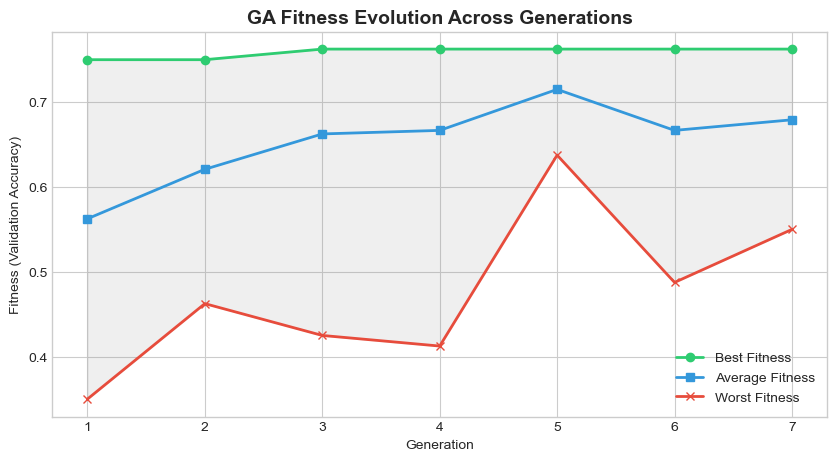

In [32]:
# ── GA Evolution visualisation ────────────────────────────────────────────────
gens_ran = len(best_fit_hist)
x_axis   = range(1, gens_ran + 1)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, best_fit_hist,  marker='o', label='Best Fitness',    color='#2ecc71', linewidth=2)
plt.plot(x_axis, avg_fit_hist,   marker='s', label='Average Fitness', color='#3498db', linewidth=2)
plt.plot(x_axis, worst_fit_hist, marker='x', label='Worst Fitness',   color='#e74c3c', linewidth=2)
plt.fill_between(x_axis, worst_fit_hist, best_fit_hist, alpha=0.12, color='gray')
plt.title('GA Fitness Evolution Across Generations', fontsize=14, fontweight='bold')
plt.xlabel('Generation')
plt.ylabel('Fitness (Validation Accuracy)')
plt.xticks(x_axis)
plt.legend()
plt.savefig('05_ga_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

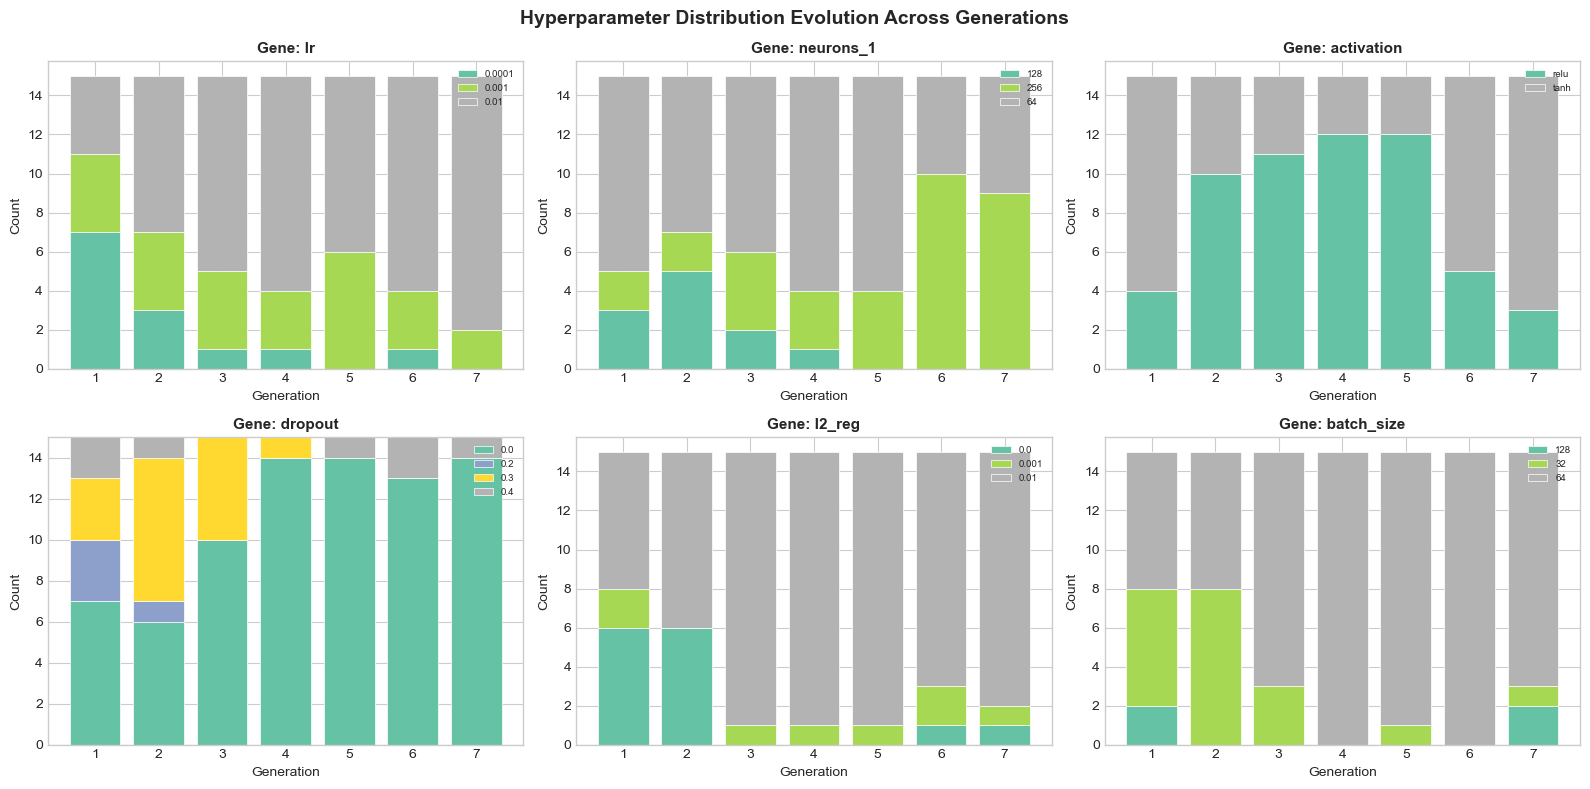

In [33]:
# ── Hyperparameter distribution evolution ─────────────────────────────────────
# Show how the most impactful genes shift across generations
genes_to_plot = ['lr', 'neurons_1', 'activation', 'dropout', 'l2_reg', 'batch_size']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, gene in zip(axes, genes_to_plot):
    values_over_gens = hyperparam_hist[gene]   # list of lists
    unique_vals = sorted(set(str(v) for g in values_over_gens for v in g))
    counts = np.array([[list(map(str, g)).count(v) for v in unique_vals]
                        for g in values_over_gens])

    bottom = np.zeros(len(values_over_gens))
    palette = plt.cm.Set2(np.linspace(0, 1, len(unique_vals)))
    for i, (val, color) in enumerate(zip(unique_vals, palette)):
        ax.bar(range(1, len(values_over_gens)+1), counts[:, i],
               bottom=bottom, label=str(val), color=color, edgecolor='white', linewidth=0.5)
        bottom += counts[:, i]

    ax.set_title(f'Gene: {gene}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Hyperparameter Distribution Evolution Across Generations',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_hyperparam_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
GA_CONFIG = {
    'pop_size'        : 15,
    'generations'     : 10,
    'tournament_size' : 3,
    'crossover_prob'  : 0.75,
    'mutation_prob'   : 0.10,
    'elitism_count'   : 2,
    'fitness_epochs'  : 3,
    'fitness_subset'  : 400,
}

fitness_cache = {}

def chrom_key(chrom):
    return str(sorted(chrom.items()))

def fitness_function_cached(chrom):
    key = chrom_key(chrom)
    if key in fitness_cache:
        return fitness_cache[key]

    n = GA_CONFIG['fitness_subset']
    idx = np.random.choice(len(X_train_val), n, replace=False)
    Xs, ys = X_train_val[idx], y_train_val[idx]

    X_t, X_v, y_t, y_v = train_test_split(
        Xs, ys, test_size=0.2, stratify=ys, random_state=42
    )

    tf.keras.backend.clear_session()
    m = build_model_from_chromosome(X_t.shape[1], chrom)
    m.fit(X_t, y_t, validation_data=(X_v, y_v),
          epochs=GA_CONFIG['fitness_epochs'],
          batch_size=chrom['batch_size'], verbose=0)
    _, acc = m.evaluate(X_v, y_v, verbose=0)
    fitness_cache[key] = float(acc)
    return float(acc)

In [36]:
population = [random_chromosome() for _ in range(GA_CONFIG['pop_size'])]

best_fit_hist, avg_fit_hist, worst_fit_hist = [], [], []
hyperparam_hist = {gene: [] for gene in GENE_SPACE}
overall_best_chrom   = None
overall_best_fitness = 0.0

print('=== Genetic Algorithm Started ===')

for gen in range(GA_CONFIG['generations']):
    t0 = time.time()

    fitnesses = [fitness_function_cached(ind) for ind in population]

    paired     = sorted(zip(fitnesses, population), key=lambda x: x[0], reverse=True)
    fitnesses  = [p[0] for p in paired]
    population = [p[1] for p in paired]

    best_fit_hist.append(fitnesses[0])
    avg_fit_hist.append(np.mean(fitnesses))
    worst_fit_hist.append(fitnesses[-1])

    for gene in GENE_SPACE:
        hyperparam_hist[gene].append([ind[gene] for ind in population])

    # ── همیشه بهترین رو ذخیره کن ─────────────────────────────────────
    if fitnesses[0] > overall_best_fitness:
        overall_best_fitness = fitnesses[0]
        overall_best_chrom   = population[0].copy()

    print(f'Gen {gen+1:2d}/{GA_CONFIG["generations"]} | '
          f'Best={fitnesses[0]:.4f} | Avg={np.mean(fitnesses):.4f} | '
          f'Worst={fitnesses[-1]:.4f} | Time={time.time()-t0:.1f}s')

    new_population = population[:GA_CONFIG['elitism_count']]
    while len(new_population) < GA_CONFIG['pop_size']:
        parent1 = tournament_selection(population, fitnesses)
        parent2 = tournament_selection(population, fitnesses)
        child1, child2 = uniform_crossover(parent1, parent2)
        child1 = mutate(child1)
        child2 = mutate(child2)
        new_population.append(child1)
        if len(new_population) < GA_CONFIG['pop_size']:
            new_population.append(child2)
    population = new_population

    if len(best_fit_hist) >= 5 and np.std(best_fit_hist[-5:]) < 0.001:
        print(f'Converged at generation {gen+1}.')
        break

# ── اگه به هر دلیلی None موند ─────────────────────────────────────────
if overall_best_chrom is None:
    overall_best_chrom = population[0].copy()
    overall_best_fitness = fitnesses[0]

print(f'\n=== GA Complete ===')
print(f'Best fitness : {overall_best_fitness:.4f}')
print(f'Best params  : {overall_best_chrom}')

=== Genetic Algorithm Started ===
Gen  1/10 | Best=0.7500 | Avg=0.5792 | Worst=0.4125 | Time=70.5s
Gen  2/10 | Best=0.7500 | Avg=0.6458 | Worst=0.4500 | Time=51.6s
Gen  3/10 | Best=0.7500 | Avg=0.6783 | Worst=0.3625 | Time=34.7s
Gen  4/10 | Best=0.7500 | Avg=0.6858 | Worst=0.4125 | Time=30.9s
Gen  5/10 | Best=0.7500 | Avg=0.7117 | Worst=0.5250 | Time=26.4s
Converged at generation 5.

=== GA Complete ===
Best fitness : 0.7500
Best params  : {'hidden_layers': 2, 'neurons_1': 64, 'neurons_2': 256, 'lr': 0.0001, 'activation': 'relu', 'dropout': 0.2, 'l2_reg': 0.01, 'batch_size': 128}


In [37]:
# ── Build model for each condition ────────────────────────────────────────────
def create_condition_model(input_dim, params, use_l2=False, use_dropout=False):
    reg      = l2(params['l2_reg'])  if (use_l2      and params['l2_reg']  > 0) else None
    drop_r   = params['dropout']     if (use_dropout and params['dropout'] > 0) else 0.0

    model = Sequential()
    model.add(Dense(params['neurons_1'],
                    activation=params['activation'],
                    kernel_regularizer=reg,
                    input_shape=(input_dim,)))
    if drop_r > 0:
        model.add(Dropout(drop_r))

    if params['hidden_layers'] == 2:
        model.add(Dense(params['neurons_2'],
                        activation=params['activation'],
                        kernel_regularizer=reg))
        if drop_r > 0:
            model.add(Dropout(drop_r))

    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=params['lr']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Condition definitions ─────────────────────────────────────────────────────
BASELINE_PARAMS = {
    'hidden_layers': 2, 'neurons_1': 128, 'neurons_2': 128,
    'lr': 0.001, 'activation': 'relu',
    'dropout': 0.0, 'l2_reg': 0.0, 'batch_size': 32
}

CONDITIONS = {
    'A_Baseline': {'params': BASELINE_PARAMS,       'l2': False, 'drop': False},
    'B_L2'      : {'params': overall_best_chrom,    'l2': True,  'drop': False},
    'C_Dropout' : {'params': overall_best_chrom,    'l2': False, 'drop': True},
    'D_Combined': {'params': overall_best_chrom,    'l2': True,  'drop': True},
}

histories_cond = {}
models_cond    = {}

print('Training all four regularisation conditions...')
for cond_name, cfg in CONDITIONS.items():
    print(f'  Training {cond_name}...')
    m = create_condition_model(
        X_train.shape[1], cfg['params'],
        use_l2=cfg['l2'], use_dropout=cfg['drop']
    )
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    h  = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=int(cfg['params']['batch_size']),
        class_weight=CLASS_WEIGHTS,
        callbacks=[es],
        verbose=0
    )
    histories_cond[cond_name] = h
    models_cond[cond_name]    = m
    print(f'    Done — {len(h.epoch)} epochs.')

print('All conditions trained.')

Training all four regularisation conditions...
  Training A_Baseline...
    Done — 11 epochs.
  Training B_L2...
    Done — 47 epochs.
  Training C_Dropout...
    Done — 27 epochs.
  Training D_Combined...
    Done — 55 epochs.
All conditions trained.


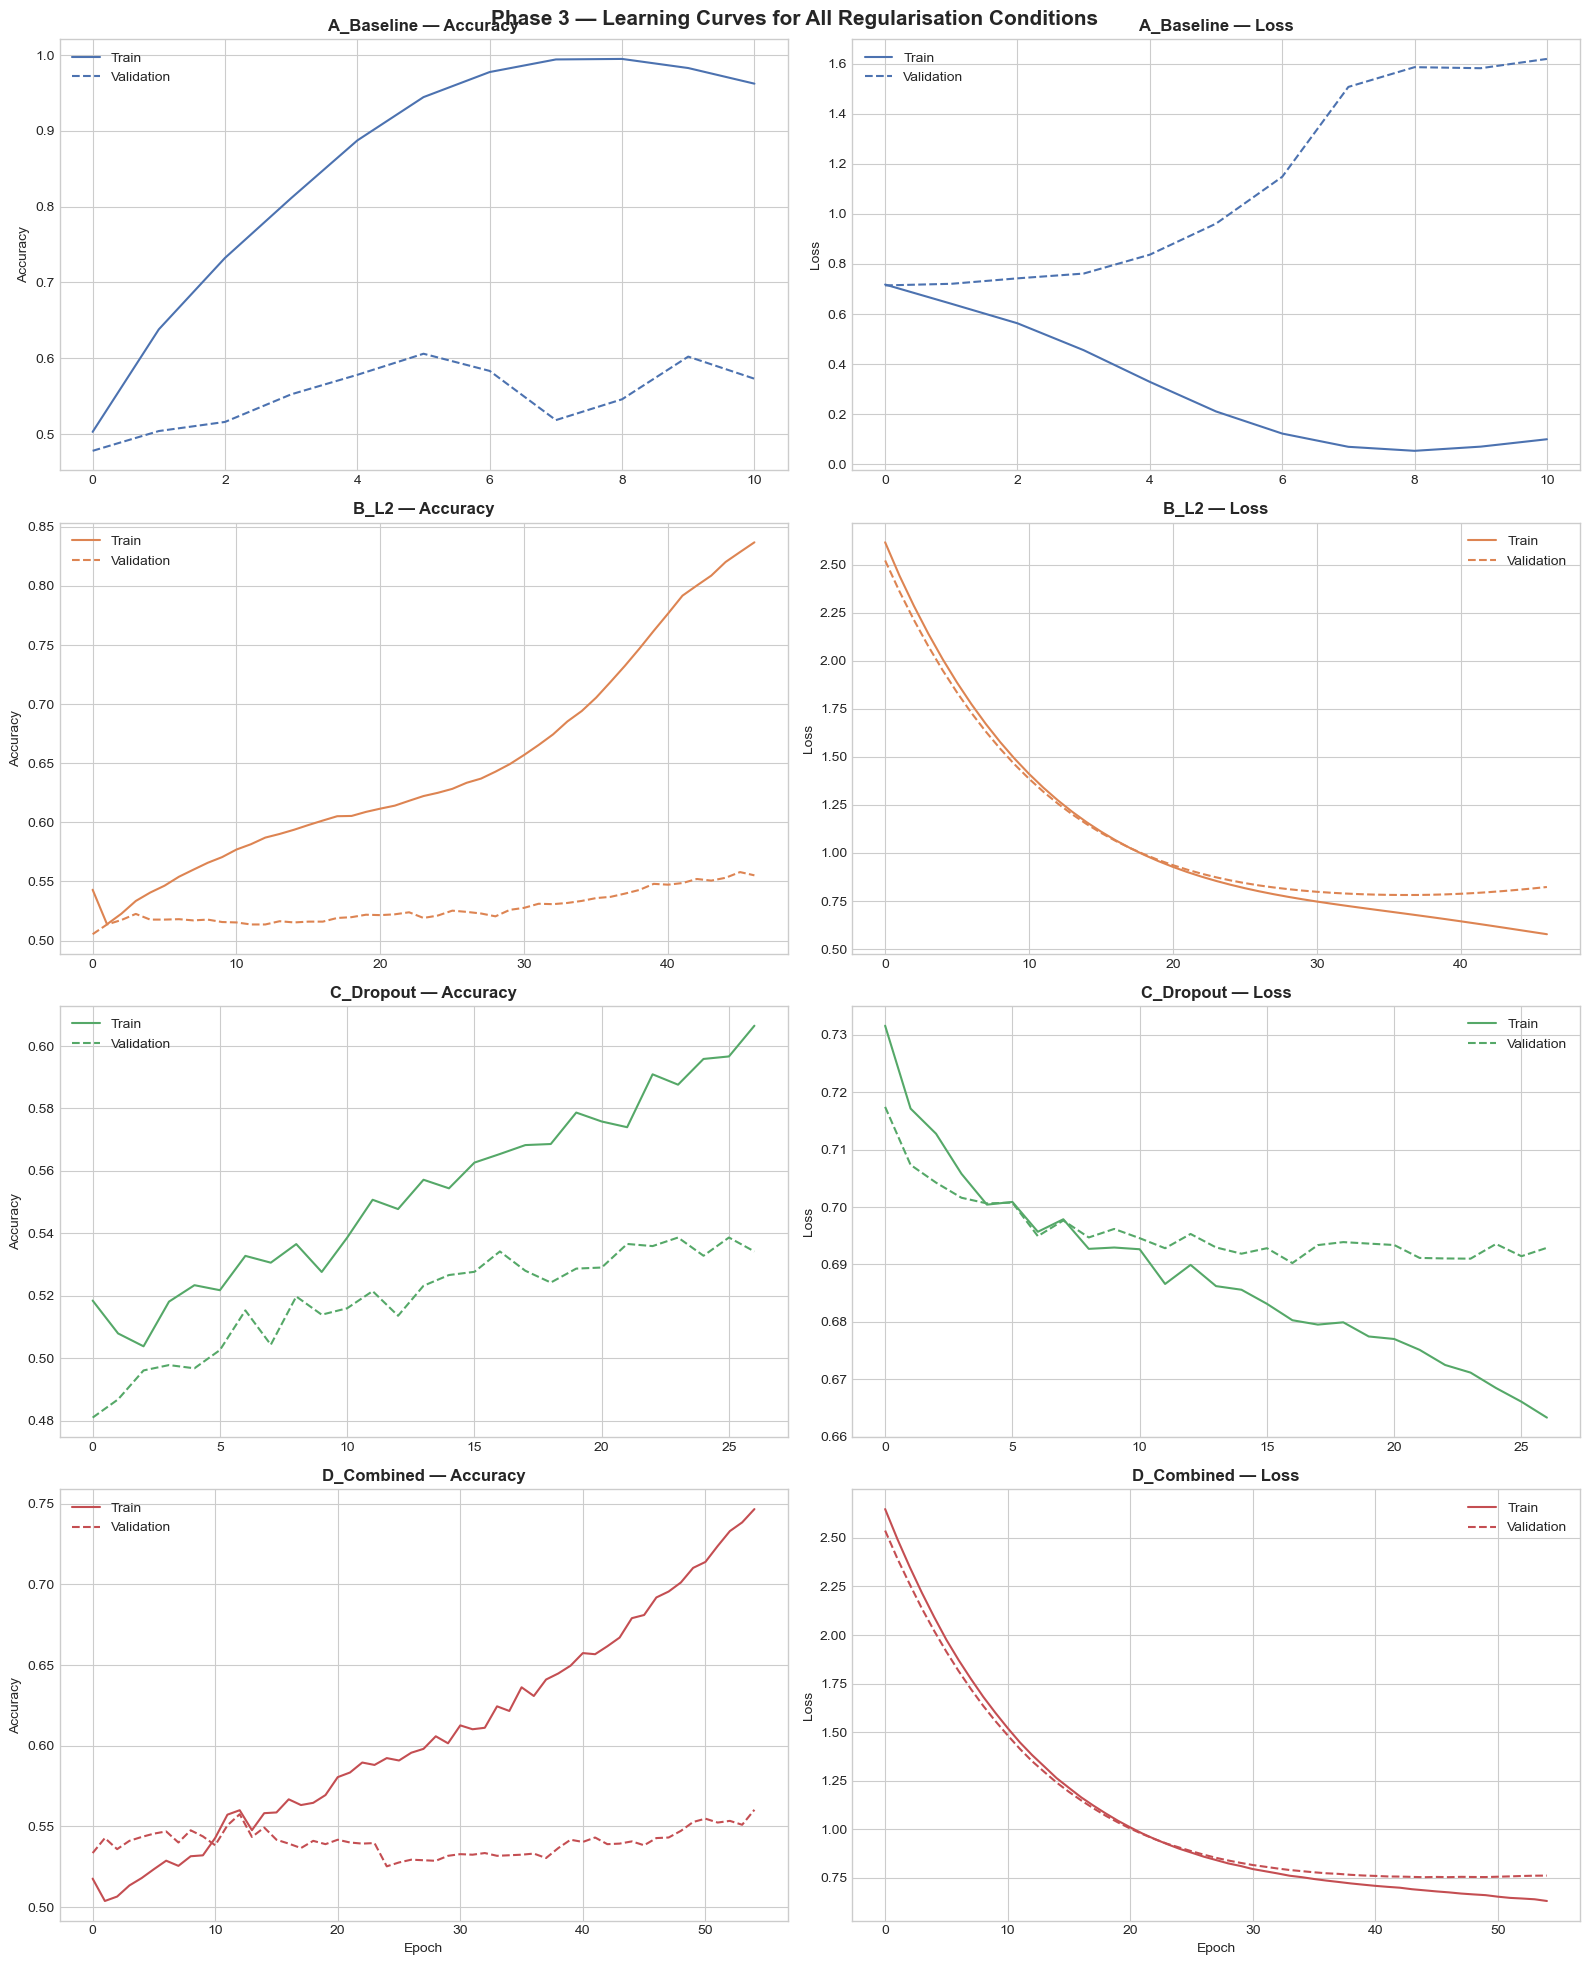

In [38]:
# ── Learning curves for all 4 conditions ──────────────────────────────────────
cond_labels   = list(CONDITIONS.keys())
cond_colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for row, (cond, color) in enumerate(zip(cond_labels, cond_colors)):
    h = histories_cond[cond]

    # Accuracy
    axes[row, 0].plot(h.history['accuracy'],     label='Train',      color=color, linewidth=1.5)
    axes[row, 0].plot(h.history['val_accuracy'], label='Validation', color=color, linewidth=1.5, linestyle='--')
    axes[row, 0].set_title(f'{cond} — Accuracy', fontweight='bold')
    axes[row, 0].set_ylabel('Accuracy')
    axes[row, 0].legend()

    # Loss
    axes[row, 1].plot(h.history['loss'],     label='Train',      color=color, linewidth=1.5)
    axes[row, 1].plot(h.history['val_loss'], label='Validation', color=color, linewidth=1.5, linestyle='--')
    axes[row, 1].set_title(f'{cond} — Loss', fontweight='bold')
    axes[row, 1].set_ylabel('Loss')
    axes[row, 1].legend()

for ax in axes[-1]:
    ax.set_xlabel('Epoch')

plt.suptitle('Phase 3 — Learning Curves for All Regularisation Conditions',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('07_regularisation_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

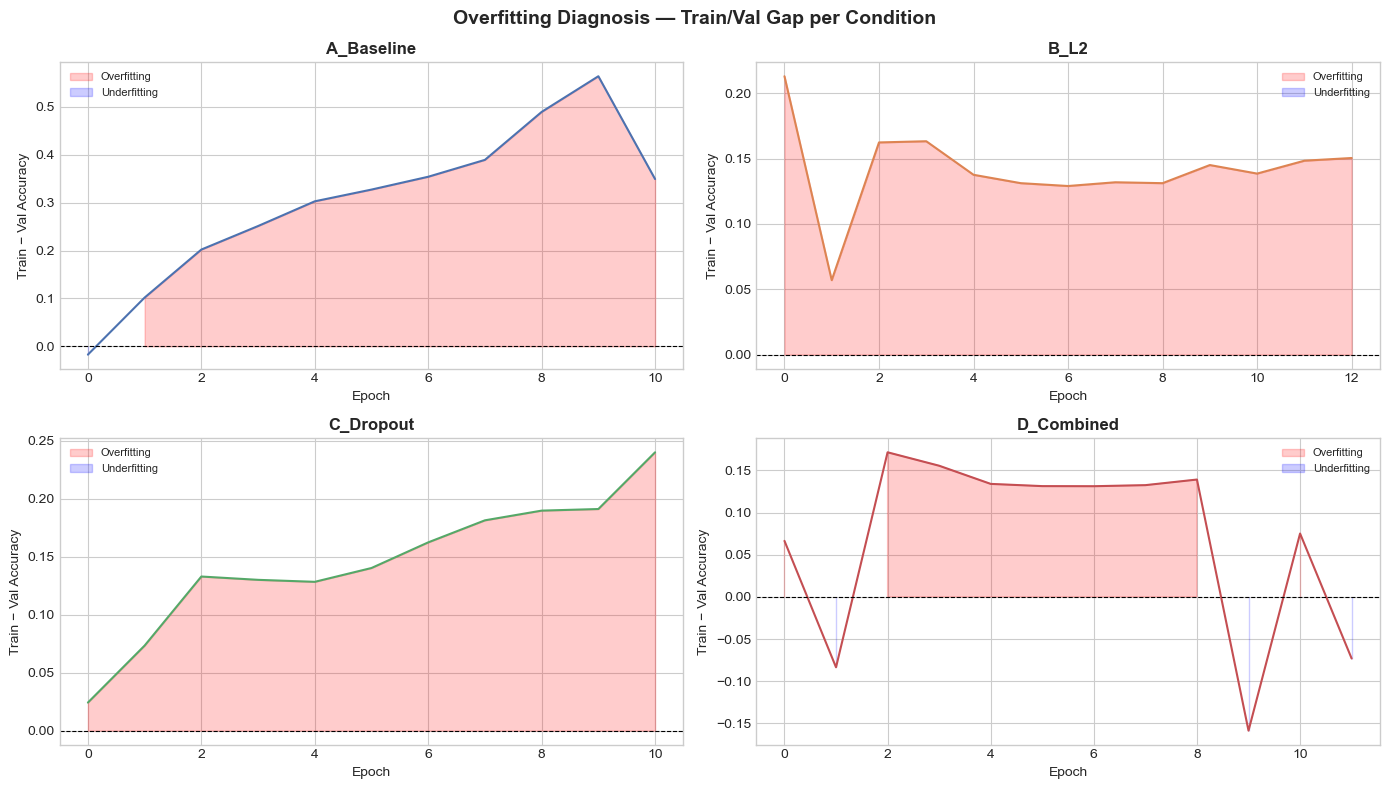

In [20]:
# ── Overfitting gap for all conditions ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (cond, color) in zip(axes, zip(cond_labels, cond_colors)):
    h   = histories_cond[cond]
    gap = np.array(h.history['accuracy']) - np.array(h.history['val_accuracy'])
    ax.plot(gap, color=color, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.fill_between(range(len(gap)), gap, 0, where=(gap > 0), alpha=0.2, color='red',  label='Overfitting')
    ax.fill_between(range(len(gap)), gap, 0, where=(gap < 0), alpha=0.2, color='blue', label='Underfitting')
    ax.set_title(f'{cond}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train − Val Accuracy')
    ax.legend(fontsize=8)

plt.suptitle('Overfitting Diagnosis — Train/Val Gap per Condition',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_overfitting_gap_all_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


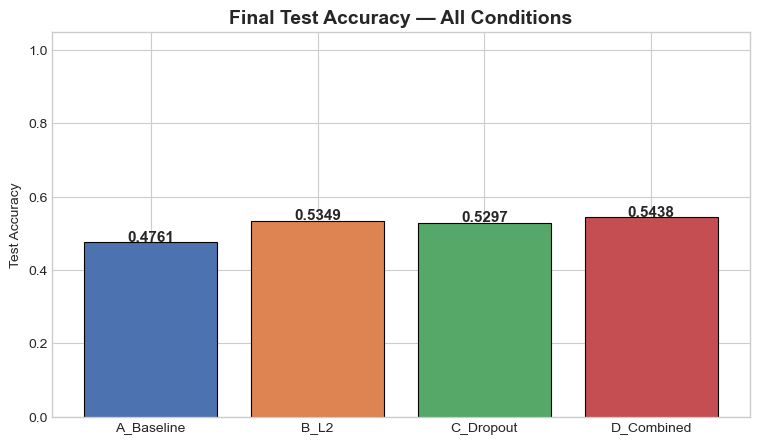

In [39]:
# ── Collect test metrics ───────────────────────────────────────────────────────
results = {}
for cond, m in models_cond.items():
    _, acc   = m.evaluate(X_test, y_test, verbose=0)
    y_prob   = m.predict(X_test).ravel()
    y_pred   = (y_prob > 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results[cond] = {
        'acc'   : acc,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'fpr'   : fpr,
        'tpr'   : tpr,
        'auc'   : auc(fpr, tpr),
    }

# ── Bar chart: test accuracy ───────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
bar_vals  = [results[c]['acc'] for c in cond_labels]
bars = plt.bar(cond_labels, bar_vals, color=cond_colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, bar_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003, f'{val:.4f}',
             ha='center', fontweight='bold', fontsize=11)
plt.title('Final Test Accuracy — All Conditions', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05)
plt.savefig('09_test_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()

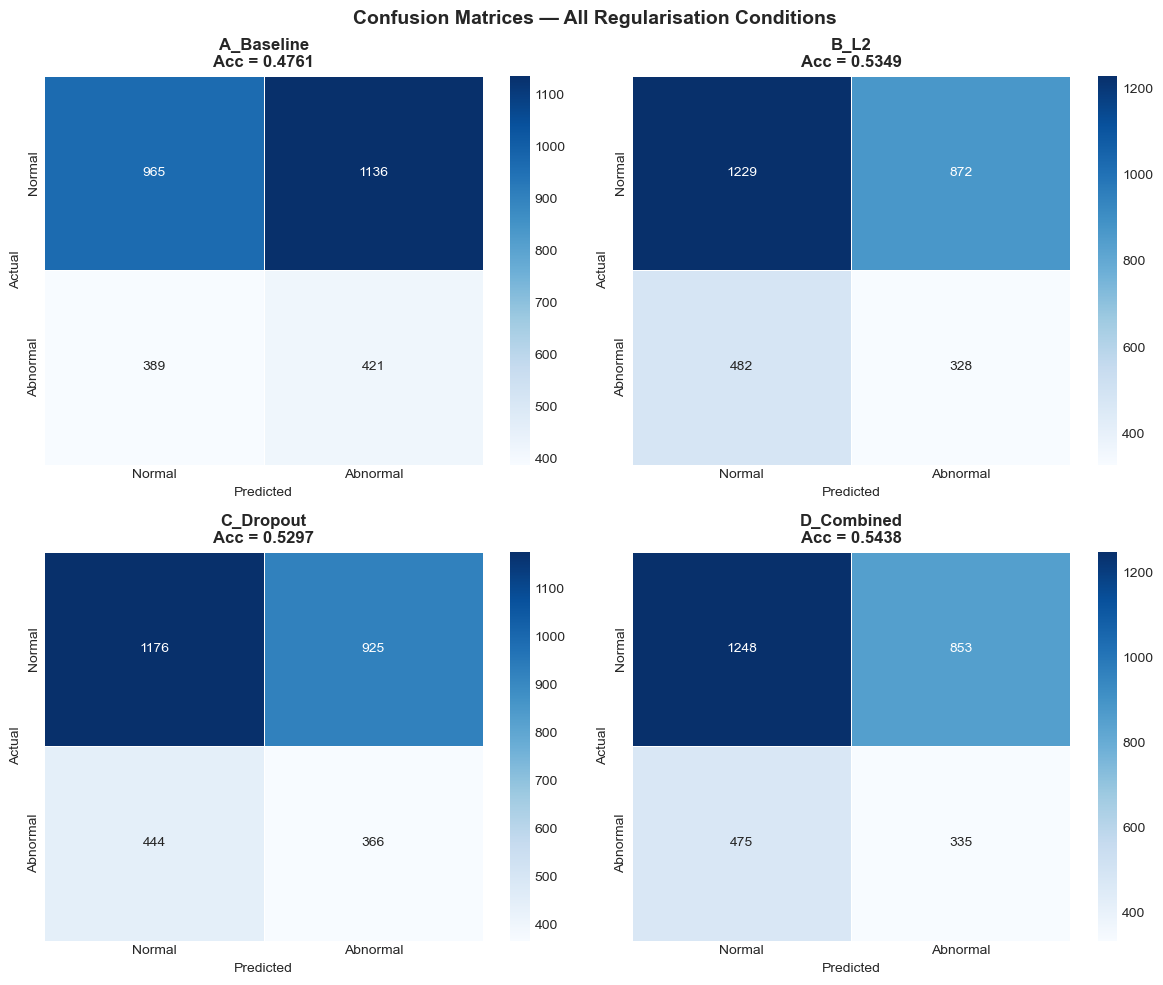

In [40]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (cond, color) in zip(axes, zip(cond_labels, cond_colors)):
    cm = confusion_matrix(y_test, results[cond]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Abnormal'],
                yticklabels=['Normal', 'Abnormal'],
                ax=ax, linewidths=0.5)
    ax.set_title(f'{cond}\nAcc = {results[cond]["acc"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Regularisation Conditions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

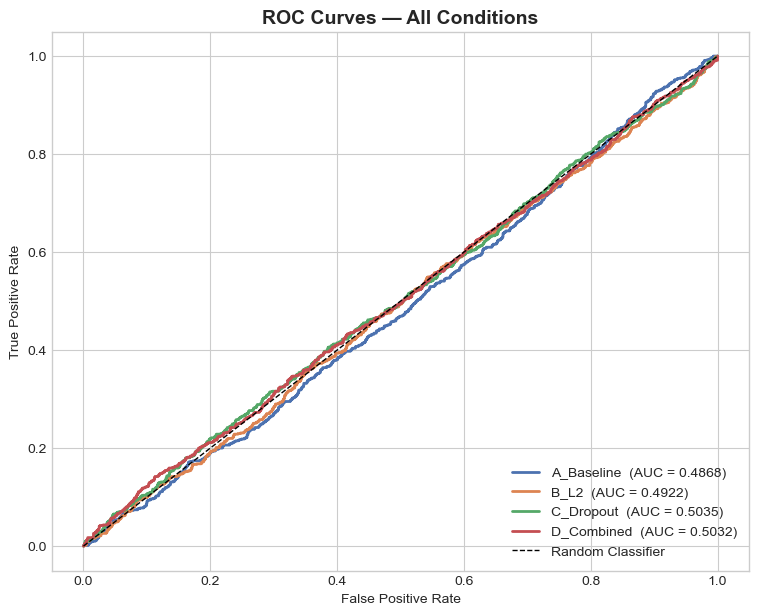

In [42]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
for cond, color in zip(cond_labels, cond_colors):
    r = results[cond]
    plt.plot(r['fpr'], r['tpr'],
             label=f'{cond}  (AUC = {r["auc"]:.4f})',
             color=color, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.title('ROC Curves — All Conditions', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.savefig('11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ── Classification reports ─────────────────────────────────────────────────────
print('=' * 60)
for cond in cond_labels:
    print(f'\n--- Classification Report: {cond} ---')
    print(classification_report(
        y_test, results[cond]['y_pred'],
        target_names=['Normal', 'Abnormal']
    ))
print('=' * 60)


--- Classification Report: A_Baseline ---
              precision    recall  f1-score   support

      Normal       0.71      0.46      0.56      2101
    Abnormal       0.27      0.52      0.36       810

    accuracy                           0.48      2911
   macro avg       0.49      0.49      0.46      2911
weighted avg       0.59      0.48      0.50      2911


--- Classification Report: B_L2 ---
              precision    recall  f1-score   support

      Normal       0.72      0.58      0.64      2101
    Abnormal       0.27      0.40      0.33       810

    accuracy                           0.53      2911
   macro avg       0.50      0.49      0.49      2911
weighted avg       0.59      0.53      0.56      2911


--- Classification Report: C_Dropout ---
              precision    recall  f1-score   support

      Normal       0.73      0.56      0.63      2101
    Abnormal       0.28      0.45      0.35       810

    accuracy                           0.53      2911
   mac

 Condition  Test Accuracy    AUC  Precision  Recall  F1-Score  Avg Overfit Gap
A_Baseline         0.4761 0.4868     0.2704  0.5198    0.3557           0.3066
      B_L2         0.5349 0.4922     0.2733  0.4049    0.3264           0.1193
 C_Dropout         0.5297 0.5035     0.2835  0.4519    0.3484           0.0347
D_Combined         0.5438 0.5032     0.2820  0.4136    0.3353           0.0758


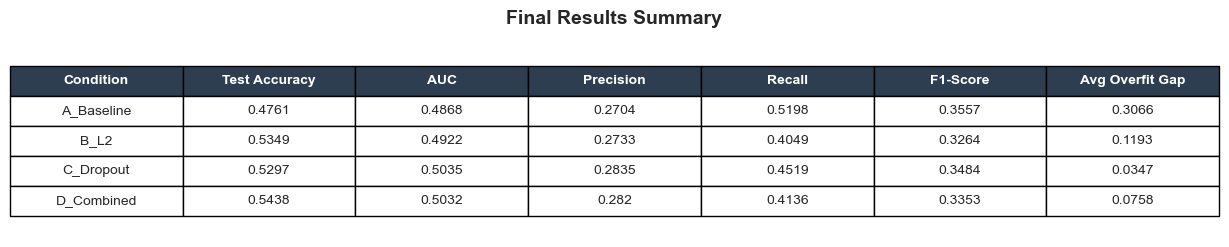

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for cond in cond_labels:
    r   = results[cond]
    yp  = r['y_pred']
    h   = histories_cond[cond]
    gap = np.array(h.history['accuracy']) - np.array(h.history['val_accuracy'])
    summary_rows.append({
        'Condition'    : cond,
        'Test Accuracy': round(r['acc'], 4),
        'AUC'          : round(r['auc'], 4),
        'Precision'    : round(precision_score(y_test, yp), 4),
        'Recall'       : round(recall_score(y_test, yp), 4),
        'F1-Score'     : round(f1_score(y_test, yp), 4),
        'Avg Overfit Gap': round(float(np.mean(np.abs(gap))), 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# ── Styled table visualisation ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 2.5))
ax.axis('off')
tbl = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
for j in range(len(summary_df.columns)):
    tbl[(0, j)].set_facecolor('#2c3e50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

plt.title('Final Results Summary', fontsize=14, fontweight='bold', pad=15)
plt.savefig('12_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
try:
    normal   = pd.read_csv('ptbdb_normal.csv',   header=None)
    abnormal = pd.read_csv('ptbdb_abnormal.csv', header=None)

_IncompleteInputError: incomplete input (1071206081.py, line 3)

In [28]:
print(X.shape)
print(np.unique(y, return_counts=True))

(14552, 187)
(array([0, 1]), array([10501,  4051]))


In [29]:
print(X_train[:3])

[[ 9.85635411e-01  1.92214699e-01  3.62573829e-01  1.41784679e+00
  -2.75723879e-01  2.52595392e+00  3.35040743e-01  1.86931331e+00
  -1.03463176e+00  8.80780572e-01  4.32859165e-01  4.22808323e-01
   6.40985085e-01  2.15615783e-01  5.67917118e-01  1.18692379e+00
   1.68520853e+00 -8.43994017e-01  9.40519020e-01 -6.31751331e-01
  -7.78021696e-01 -4.16124852e-01  6.90546829e-01 -6.53470345e-01
  -8.68537117e-01  4.98473549e-01 -5.48722180e-01  1.33346400e+00
   9.00974182e-01  1.29745237e+00 -5.86193061e-01  6.23094793e-01
   7.45742319e-01  1.31398793e+00  6.07983496e-01  6.38670773e-01
  -1.43596746e+00 -9.11951739e-01  3.95765114e-01  5.31339335e-01
  -7.42656595e-02  2.08166235e-01  4.20539768e-01 -3.71942918e-01
   9.50859832e-01 -2.49699247e-01 -2.23364303e-01  1.85429509e-01
  -6.79365662e-01 -1.51141906e+00 -1.65787676e-01  1.35034703e-01
  -4.20897644e-01 -3.41560337e-01 -8.87352534e-01  2.58878182e-01
   8.85567768e-01 -3.19785791e-01  4.60037922e-02 -8.56281945e-01
   9.22738